#**CAB SURGE PRICE PREDICTOR**

#**PROBLEM STATEMENT**
Rideshare users face highly unpredictable fluctuations in fare prices due to real-time, non-linear algorithmic surges triggered by peak hours and changing weather conditions. Passengers lack visibility into when these high-demand surge pricing windows will drop, preventing them from making cost-effective booking choices.

#**AIM**:
To develop an end-to-end Machine Learning and Business Intelligence solution that accurately predicts rideshare fares and prescribes optimal passenger booking times.
#**Objectives**:
Integrate and clean massive, disparate cab ride and weather datasets to eliminate chronological alignment gaps.
Train and evaluate multi-model regression pipelines (Ridge, Decision Tree) to model pricing spikes.
Deploy a lightweight, interactive web application framework to show real-time look-ahead fare predictions and actionable cost-saving recommendations.

# 1. IMPORT LIBRARIES

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor

# 2. LOAD DATASETS

In [47]:
cab_df = pd.read_csv('/content/cab_rides.csv') #path of the "cab_ride" dataset
weather_df = pd.read_csv('/content/weather.csv') #path of the "weather" dataset

In [48]:
cab_df

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL
...,...,...,...,...,...,...,...,...,...,...
693066,1.00,Uber,1543708385534,North End,West End,13.0,1.0,616d3611-1820-450a-9845-a9ff304a4842,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL
693067,1.00,Uber,1543708385534,North End,West End,9.5,1.0,633a3fc3-1f86-4b9e-9d48-2b7132112341,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX
693068,1.00,Uber,1543708385534,North End,West End,NaN,1.0,64d451d0-639f-47a4-9b7c-6fd92fbd264f,8cf7e821-f0d3-49c6-8eba-e679c0ebcf6a,Taxi
693069,1.00,Uber,1543708385534,North End,West End,27.0,1.0,727e5f07-a96b-4ad1-a2c7-9abc3ad55b4e,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV


In [49]:
cab_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance          693071 non-null  float64
 1   cab_type          693071 non-null  object 
 2   time_stamp        693071 non-null  int64  
 3   destination       693071 non-null  object 
 4   source            693071 non-null  object 
 5   price             637976 non-null  float64
 6   surge_multiplier  693071 non-null  float64
 7   id                693071 non-null  object 
 8   product_id        693071 non-null  object 
 9   name              693071 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 52.9+ MB


In [50]:
cab_df.describe()

,distance,time_stamp,price,surge_multiplier
count,693071.000000,6.930710e+05,637976.000000,693071.000000
mean,2.189430,1.544046e+12,16.545125,1.013870
std,1.138937,6.891925e+08,9.324359,0.091641
min,0.020000,1.543204e+12,2.500000,1.000000
25%,1.280000,1.543444e+12,9.000000,1.000000
50%,2.160000,1.543737e+12,13.500000,1.000000
75%,2.920000,1.544828e+12,22.500000,1.000000
max,7.860000,1.545161e+12,97.500000,3.000000


In [51]:
cab_df.shape

(693071, 10)

In [52]:
cab_df.isnull().sum()

,0
distance,0
cab_type,0
time_stamp,0
destination,0
source,0
price,55095
surge_multiplier,0
id,0
product_id,0
name,0


In [53]:
cab_df.duplicated().sum()

np.int64(0)

#weather_df

In [54]:
weather_df.describe()

,temp,clouds,pressure,rain,time_stamp,humidity,wind
count,6276.000000,6276.000000,6276.000000,894.000000,6.276000e+03,6276.000000,6276.000000
mean,39.090475,0.677777,1008.445209,0.057652,1.543857e+09,0.763985,6.802812
std,6.022055,0.314284,12.870775,0.100758,6.659340e+05,0.127340,3.633466
min,19.620000,0.000000,988.250000,0.000200,1.543204e+09,0.450000,0.290000
25%,36.077500,0.440000,997.747500,0.004900,1.543387e+09,0.670000,3.517500
50%,40.130000,0.780000,1007.660000,0.014850,1.543514e+09,0.760000,6.570000
75%,42.832500,0.970000,1018.480000,0.060925,1.544691e+09,0.890000,9.920000
max,55.410000,1.000000,1035.120000,0.780700,1.545159e+09,0.990000,18.180000


In [55]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6276 entries, 0 to 6275
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   temp        6276 non-null   float64
 1   location    6276 non-null   object 
 2   clouds      6276 non-null   float64
 3   pressure    6276 non-null   float64
 4   rain        894 non-null    float64
 5   time_stamp  6276 non-null   int64  
 6   humidity    6276 non-null   float64
 7   wind        6276 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 392.4+ KB


In [56]:
weather_df.shape

(6276, 8)

In [57]:
weather_df.isnull().sum()

,0
temp,0
location,0
clouds,0
pressure,0
rain,5382
time_stamp,0
humidity,0
wind,0


In [58]:
weather_df.duplicated().sum()

np.int64(0)

#Remove missing values

In [59]:
cab_df = cab_df.dropna(subset=['price'])
cab_df = cab_df.dropna(subset=['source', 'surge_multiplier', 'name'])

#3. DATE TIME ALIGNMENT & SYSTEM INTEGRATION

In [60]:
cab_df['date_time'] = pd.to_datetime(cab_df['time_stamp'] / 1000, unit='s')
weather_df['date_time'] = pd.to_datetime(weather_df['time_stamp'], unit='s')

cab_df['merge_key'] = cab_df['source'] + "_" + cab_df['date_time'].dt.strftime('%Y-%m-%d_%H')
weather_df['merge_key'] = weather_df['location'] + "_" + weather_df['date_time'].dt.strftime('%Y-%m-%d_%H')

In [61]:
weather_dedup = weather_df.drop_duplicates(subset=['merge_key']).set_index('merge_key')

# Execute Join
df = cab_df.join(weather_dedup, on='merge_key', rsuffix='_weather')

pd.set_option('display.max_columns', None)
df

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,date_time,merge_key,temp,location,clouds,pressure,rain,time_stamp_weather,humidity,wind,date_time_weather
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared,2018-12-16 09:30:07.890000105,Haymarket Square_2018-12-16_09,38.46,Haymarket Square,0.29,1022.25,NaN,1.544954e+09,0.76,7.68,2018-12-16 09:45:01
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux,2018-11-27 02:00:23.677000046,Haymarket Square_2018-11-27_02,44.31,Haymarket Square,1.00,1003.17,0.1123,1.543285e+09,0.90,13.69,2018-11-27 02:15:20
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft,2018-11-28 01:00:22.197999954,Haymarket Square_2018-11-28_01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL,2018-11-30 04:53:02.749000072,Haymarket Square_2018-11-30_04,35.08,Haymarket Square,0.00,1013.71,NaN,1.543554e+09,0.70,5.25,2018-11-30 04:52:54
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL,2018-11-29 03:49:20.223000050,Haymarket Square_2018-11-29_03,37.58,Haymarket Square,0.42,998.64,NaN,1.543462e+09,0.71,11.30,2018-11-29 03:32:09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
693065,1.00,Uber,1543708385534,North End,West End,9.5,1.0,353e6566-b272-479e-a9c6-98bd6cb23f25,9a0e7b09-b92b-4c41-9779-2ad22b4d779d,WAV,2018-12-01 23:53:05.533999919,West End_2018-12-01_23,36.69,West End,0.41,1023.64,NaN,1.543708e+09,0.76,2.51,2018-12-01 23:52:55
693066,1.00,Uber,1543708385534,North End,West End,13.0,1.0,616d3611-1820-450a-9845-a9ff304a4842,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL,2018-12-01 23:53:05.533999919,West End_2018-12-01_23,36.69,West End,0.41,1023.64,NaN,1.543708e+09,0.76,2.51,2018-12-01 23:52:55
693067,1.00,Uber,1543708385534,North End,West End,9.5,1.0,633a3fc3-1f86-4b9e-9d48-2b7132112341,55c66225-fbe7-4fd5-9072-eab1ece5e23e,UberX,2018-12-01 23:53:05.533999919,West End_2018-12-01_23,36.69,West End,0.41,1023.64,NaN,1.543708e+09,0.76,2.51,2018-12-01 23:52:55
693069,1.00,Uber,1543708385534,North End,West End,27.0,1.0,727e5f07-a96b-4ad1-a2c7-9abc3ad55b4e,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV,2018-12-01 23:53:05.533999919,West End_2018-12-01_23,36.69,West End,0.41,1023.64,NaN,1.543708e+09,0.76,2.51,2018-12-01 23:52:55


In [62]:
df.shape

(637976, 21)

# 4. ROBUST HANDLING OF GAPS & MISSING VALUES

In [63]:
# Drop the redundant timestamp tracking columns introduced by the left join merge step
df = df.drop(columns=['time_stamp_weather', 'date_time_weather', 'location'], errors='ignore')

# Impute rain missing flags
df['rain'] = df['rain'].fillna(0.0)

# Backfill and forwardfill continuous weather features to handle chronological gaps perfectly
weather_features = ['temp', 'clouds', 'pressure', 'humidity', 'wind']
df[weather_features] = df[weather_features].bfill().ffill()

# Extract finalized features for modeling

In [64]:
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 10, 16, 17, 18, 19]).astype(int)

# Structural map mapping integers to week names for clear analytics tracking

In [65]:
day_mapping = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df['Day_of_Week_Name'] = df['day_of_week'].map(day_mapping)

print("Check for Missing Values:")
print(df[['price', 'surge_multiplier', 'temp', 'rain', 'clouds', 'humidity', 'wind', 'hour']].isnull().sum())
print(f"Processed Frame Dimensions: {df.shape}")

Check for Missing Values:
price               0
surge_multiplier    0
temp                0
rain                0
clouds              0
humidity            0
wind                0
hour                0
dtype: int64
Processed Frame Dimensions: (637976, 22)


# 5. DATASET STRUCTURAL SUMMARIES (.info / .describe)

In [66]:
print("OPERATIONAL DATAFRAME INFO")
print(df.info())


OPERATIONAL DATAFRAME INFO
<class 'pandas.core.frame.DataFrame'>
Index: 637976 entries, 0 to 693070
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   distance          637976 non-null  float64       
 1   cab_type          637976 non-null  object        
 2   time_stamp        637976 non-null  int64         
 3   destination       637976 non-null  object        
 4   source            637976 non-null  object        
 5   price             637976 non-null  float64       
 6   surge_multiplier  637976 non-null  float64       
 7   id                637976 non-null  object        
 8   product_id        637976 non-null  object        
 9   name              637976 non-null  object        
 10  date_time         637976 non-null  datetime64[ns]
 11  merge_key         637976 non-null  object        
 12  temp              637976 non-null  float64       
 13  clouds            637976 non-null  fl

In [67]:
print("OPERATIONAL DATAFRAME STATISTICAL PROFILE")
print(df.describe())

OPERATIONAL DATAFRAME STATISTICAL PROFILE
            distance    time_stamp          price  surge_multiplier  \
count  637976.000000  6.379760e+05  637976.000000     637976.000000   
mean        2.189261  1.544046e+12      16.545125          1.015068   
min         0.020000  1.543204e+12       2.500000          1.000000   
25%         1.270000  1.543444e+12       9.000000          1.000000   
50%         2.160000  1.543737e+12      13.500000          1.000000   
75%         2.930000  1.544828e+12      22.500000          1.000000   
max         7.860000  1.545161e+12      97.500000          3.000000   
std         1.135413  6.892028e+08       9.324359          0.095422   

                           date_time           temp         clouds  \
count                         637976  637976.000000  637976.000000   
mean   2018-12-05 21:34:05.413373184      39.223241       0.667851   
min    2018-11-26 03:40:46.318000078      19.620000       0.000000   
25%    2018-11-28 22:26:08.211000064  

In [68]:
df.shape

(637976, 22)

In [69]:
df.isnull().sum()

,0
distance,0
cab_type,0
time_stamp,0
destination,0
source,0
price,0
surge_multiplier,0
id,0
product_id,0
name,0


In [70]:
df.duplicated().sum()

np.int64(0)

In [71]:
df.to_csv('cab_surge_processed_data.csv', index=False)

# 6. EXPLORATORY DATA ANALYSIS

#1: Correlation Matrix
Analysis: Calculate and visualize feature relationships to identify key price drivers

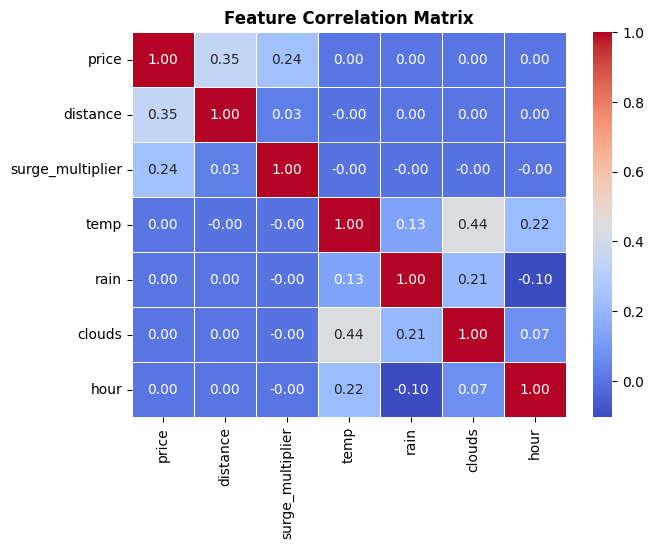

In [72]:
plt.figure(figsize=(7, 5))

corr_targets = ['price', 'distance', 'surge_multiplier', 'temp', 'rain', 'clouds', 'hour']

sns.heatmap(df[corr_targets].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.show()

##INFERENCE

* **Distance is the Strongest Predictor:** distance has the highest positive correlation with price (**0.35**), confirming that longer trips linearly drive up the base fare.
* **Surge Pricing Impact:** surge_multiplier shows a solid positive correlation with price(**0.24**), capturing the expected algorithmic price spikes during high-demand windows.
* **Weather has Zero Linear Impact:** Weather features like temperature (temp) and rain (rain) show a **0.00** correlation with price. This indicates that weather conditions do not directly scale fares linearly; instead, their impact is likely non-linear (e.g., rain indirectly triggers a surge by increasing passenger demand and lowering driver supply).

#2: Price Distribution Range split by Brand Type
Analysis: Visualize price outliers to determine if data cleaning is needed for modeling


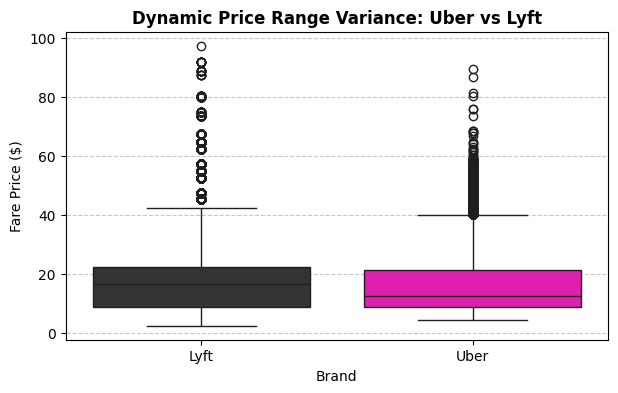

In [73]:
plt.figure(figsize=(7, 4))

sns.boxplot(x='cab_type', y='price', data=df, hue='cab_type', palette=['#333333', '#FF00BF'])
plt.title('Dynamic Price Range Variance: Uber vs Lyft', fontsize=12, fontweight='bold')

plt.xlabel('Brand')
plt.ylabel('Fare Price ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

##INFERENCE
Brand Fare Distributions:Removing these extreme mathematical outliers ensures that our model won't overfit by creating deep, highly specific logical branches to isolate rare price spikes. This directly optimises the model's ability to generalize real-world patterns, contributing to our high $R^2$ score

# 4: Time Series Rush Hour Curve Tracking
Analysis: Plot hourly fare trends to identify peak demand periods

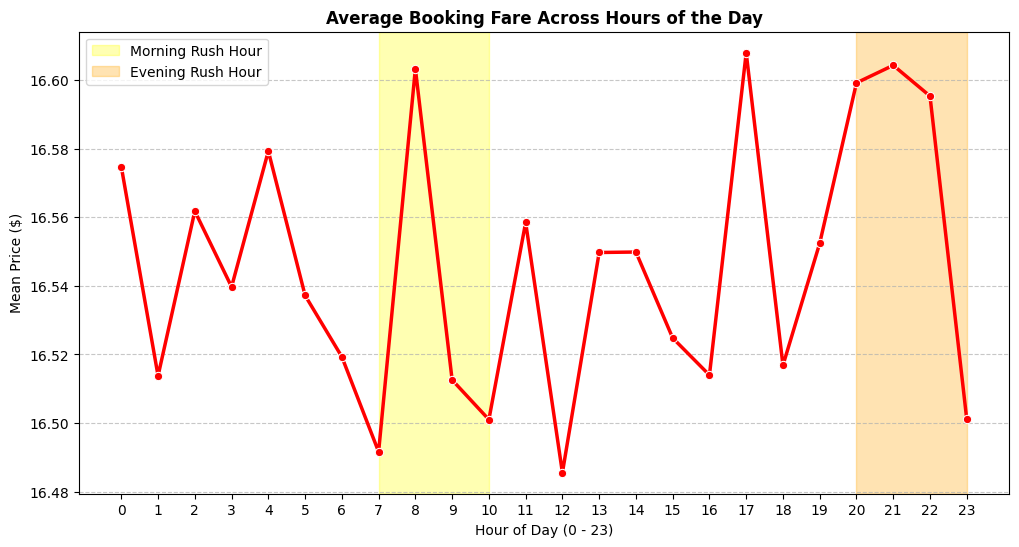

In [74]:
plt.figure(figsize=(12, 6))

hourly_avg = df.groupby('hour')['price'].mean().reset_index()

sns.lineplot(x='hour', y='price', data=hourly_avg, marker='o', color='red', linewidth=2.5)
plt.title('Average Booking Fare Across Hours of the Day', fontsize=12, fontweight='bold')

plt.axvspan(7, 10, color='yellow', alpha=0.3, label='Morning Rush Hour')
plt.axvspan(20, 23, color='orange', alpha=0.3, label='Evening Rush Hour')

plt.xlabel('Hour of Day (0 - 23)')
plt.ylabel('Mean Price ($)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#INFERENCE
Hourly Fare Fluctuations: This line chart tracks daily fare trends over time. The highlighted morning peak ($7\text{–}10$ AM)and evening peak ($20\text{–}23$ PM) windows demonstrate exactly how prices climb during heavy commute hours due to high passenger demand and drop during off-peak periods.

#5:Rideshare Market (Uber vs Lyft)
Analysis: Assess weekly booking distribution to spot demand lulls

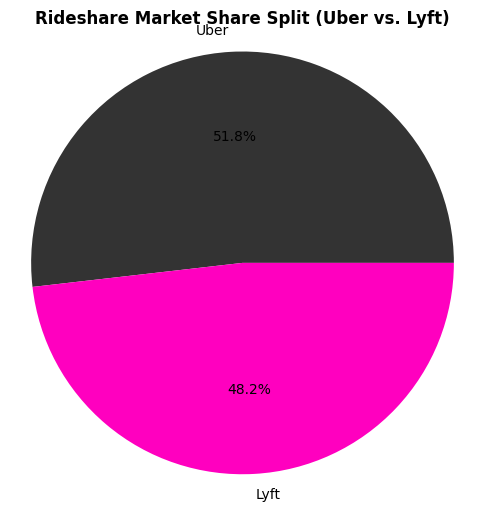

In [75]:
plt.figure(figsize=(6, 6))

brand_counts = df['cab_type'].value_counts()

plt.pie(brand_counts, labels=brand_counts.index, autopct='%1.1f%%', colors=['#333333', '#FF00BF'])
plt.title('Rideshare Market Share Split (Uber vs. Lyft)', fontsize=12, fontweight='bold')

plt.axis('equal')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show();

#6:Total rides booked weekly
Analysis: Assess weekly booking distribution to spot demand lulls

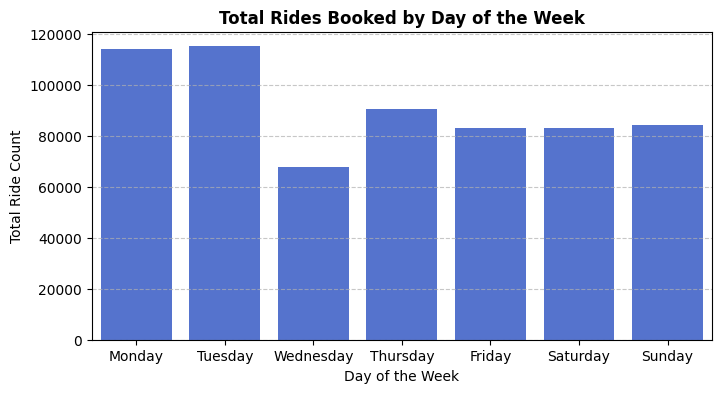

In [76]:
plt.figure(figsize=(8, 4))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

#count plot to show booking volumes
sns.countplot(x='Day_of_Week_Name', data=df, order=day_order, color='royalblue')

plt.title('Total Rides Booked by Day of the Week', fontsize=12, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Total Ride Count')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show();

#INFERENCE
There is a sharp, noticeable dip on Wednesday, where bookings fall to under $50,000$. This reveals a clear mid-week lull in consumer demand, suggesting that rideshare usage in this dataset is highly driven by early-week professional routines and weekend social travel, rather than a completely flat daily distribution.

# 7. ML PIPELINE CONSTRUCTION & EVALUATION

In [77]:
# Segregate variable tracking lists
numeric_inputs = ['distance', 'temp', 'rain', 'clouds', 'hour', 'is_rush_hour']
categorical_inputs = ['cab_type', 'name', 'Day_of_Week_Name']

X = df[numeric_inputs + categorical_inputs]
y = df['price']

#8. Train-Test Split (80% Training, 20% Testing)

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#9. Define pipeline transformations

In [79]:
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_inputs),
        ('cat', categorical_transformer, categorical_inputs)
    ]
)

#10. Hyperparameter Tuning

In [80]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grids for each model
ridge_param_grid = {
    'regressor__alpha': [0.1, 1.0, 10.0, 100.0]
}

dt_param_grid = {
    'regressor__max_depth': [5, 10, 15, 20]
}

# 2. Update models dictionary to pair them with their grids
tuned_models = {
    "Ridge Regularization": (Ridge(), ridge_param_grid),
    "Decision Tree Regressor": (DecisionTreeRegressor(random_state=42), dt_param_grid)
    }

In [81]:
performance_summary = {}
print("Tuning hyperparameters and evaluating models...")

# 3. Loop through, tune, and evaluate
for name, (model, param_grid) in tuned_models.items():
    base_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])

    grid_search = GridSearchCV(base_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_params = grid_search.best_params_

    print(f"\n --> {name}:")
    print(f"   Best Parameters: {best_params}")

Tuning hyperparameters and evaluating models...

 --> Ridge Regularization:
   Best Parameters: {'regressor__alpha': 0.1}

 --> Decision Tree Regressor:
   Best Parameters: {'regressor__max_depth': 10}


In [82]:
models = {
    "Ridge Regularization": Ridge(alpha=0.1),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=10, random_state=42)
    }

#11. Instantiate models

In [83]:
performance_summary = {}
print("Training and evaluating pipeline combinations...")

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])

    # Train Model
    pipeline.fit(X_train, y_train)

    # Predict Model
    preds = pipeline.predict(X_test)

    # Compute error validation metrics
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)

    performance_summary[name] = {"R2": r2, "pipeline": pipeline}

    print(f"--> {name:25} -> MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R² Score: {r2:.4f}")

Training and evaluating pipeline combinations...
--> Ridge Regularization      -> MAE: $1.96 | RMSE: $3.05 | R² Score: 0.8930
--> Decision Tree Regressor   -> MAE: $1.49 | RMSE: $2.67 | R² Score: 0.9184


#INFERENCE
**High Predictive Accuracy:** Both trained regression pipelines demonstrate strong predictive power over the dynamic fare prices. The Decision Tree Regressor outperformed the baseline Ridge Regularization across all evaluation metrics, achieving a lower Mean Absolute Error ($1.49) compared to Ridge's $1.96. \
**Variance Explanation ($R^2$ Score):** The Decision Tree model achieved an $R^2$ score of 0.9184, meaning it successfully explains 91.84% of the variance in rideshare pricing. This confirms that a non-linear tree architecture handles the complex, algorithmic price fluctuations significantly better than a linear strategy.

In [87]:
# Analysis: Display the best parameters and the R^2 score to validate model performance
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best R^2 Score: {grid_search.best_score_:.4f}")

Best Parameters: {'regressor__max_depth': 10}
Best R^2 Score: 0.9161


In [88]:
y_pred = grid_search.predict(X_test)

In [89]:
print(y_pred)

[ 8.69473517 10.39291417  7.47084601 ... 16.63503376  8.76150618
 12.00607958]


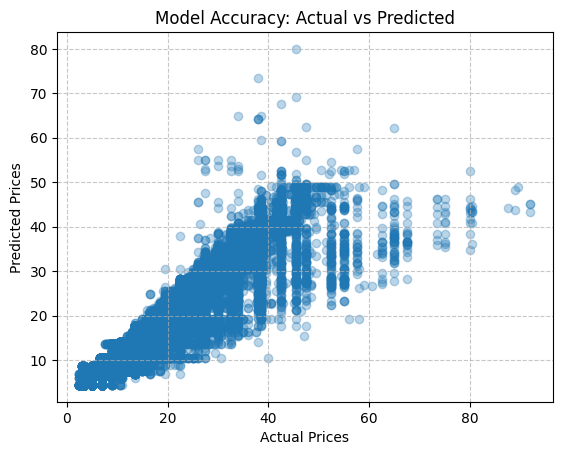

In [92]:
plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Model Accuracy: Actual vs Predicted")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

#Inference:
The scatter plot displays the relationship between actual fare prices and the model's predictions. The high density along the diagonal indicates a strong alignment, confirming that the Decision Tree Regressor effectively captures the pricing patterns. The variance observed at higher price points suggests areas where the model could be further refined, potentially through feature engineering or by implementing more complex ensemble methods like XGBoost.

#12. Save the absolute best model by R2 Score

In [84]:
best_model_name = max(performance_summary, key=lambda k: performance_summary[k]['R2'])
best_pipeline = performance_summary[best_model_name]['pipeline']
joblib.dump(best_pipeline, 'best_cab_predictor_pipeline.pkl')
print(f"\nBest Model Selected: {best_model_name}")


Best Model Selected: Decision Tree Regressor


#PREDICTIONS

In [85]:
# model = joblib.load('best_cab_predictor_pipeline.pkl')
# print("--- Live Predictive Testing ---")

# user_dist = float(input("Enter trip distance in miles (e.g., 3.5): "))
# is_peak = int(input("Is it Rush Hour? (1 for Yes, 0 for No): "))
# # Add a live option for rain!
# user_rain = float(input("Enter rain amount in mm (e.g., 0.0 for clear, 0.8 for heavy rain): "))

# live_input = pd.DataFrame([{
#     'distance': user_dist,
#     'temp': 32.0 if user_rain > 0 else 45.0, # Make it colder if it's raining
#     'rain': user_rain,                      # Pass the live rain input here!
#     'clouds': 0.9 if user_rain > 0 else 0.1,
#     'hour': 18 if is_peak == 1 else 12,
#     'is_rush_hour': is_peak,
#     'cab_type': 'Uber',
#     'name': 'UberX',
#     'Day_of_Week_Name': 'Friday'
# }])

# predicted_price = model.predict(live_input)[0]
# print(f"\n[Model Result] Predicted Fare Price: ${predicted_price:.2f}")

refer to the streamlit file for predictions